<a href="https://colab.research.google.com/github/will-mccormack/CS-M148-Proj/blob/main/Project_4_Check_In.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install scikit-lego
%pip install -U kaleido
%pip install plotly
%pip install plotly --upgrade

In [2]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import time
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import plotly.io as pio
pio.get_chrome()
pio.renderers.default = 'png'

In [3]:
cleaned_data = pd.read_csv("https://raw.githubusercontent.com/will-mccormack/CS-M148-Proj/main/Data/train.csv")
validation_data = pd.read_csv("https://raw.githubusercontent.com/will-mccormack/CS-M148-Proj/main/Data/validation.csv")

In [4]:
# drop features we've determined in previous weeks
#drop_col_train = ["key","time_signature"]
drop_col = ["key","acousticness","time_signature"]
train_data = cleaned_data.drop(drop_col, axis=1)
test_data = validation_data.drop(drop_col, axis = 1)

In [5]:
train_data.columns
test_data.columns

Index(['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'loudness', 'mode', 'speechiness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'track_genre'],
      dtype='object')

We are choosing to use KNN for our response variable 'explicit'

In [6]:
from pandas.api.types import is_string_dtype
# find knn for one row
def find_knn(k, train_data, new_point, class_col, p):
  # create empty array for minkowski distance
  distance_calc = pd.Series(np.zeros(len(train_data)), index=train_data.index)
  # go through each numeric column and calculate the distance from the test data row
  for col_name in train_data.columns:
    if (col_name != class_col) and (not is_string_dtype(train_data[col_name])):
      distance_calc += abs(train_data[col_name]-new_point[col_name])**p
    else:
      continue
  distance_calc = distance_calc**(1/p) # finish distance calc
  smallest_k = distance_calc.nsmallest(k) # find smallest distance
  smallest_k_rows = smallest_k.index # find rows that correspond
  votes = train_data.loc[smallest_k_rows,class_col] # find classifiers for smallest k
  voted_class = votes.mode()[0] # get most voted class
  return voted_class

In [7]:
from sklearn.preprocessing import StandardScaler
# find knn for entire dataset
def knn_predict(k, train_data, test_data, class_col, p):
  # find numeric columns for analysis
  numeric_cols = []
  for col_name in train_data.columns:
    if (col_name != class_col) and (not is_string_dtype(train_data[col_name])):
      numeric_cols.append(col_name)
  # scale columns so predictors on a larger scale do not dominate
  scaler = StandardScaler()
  scaler.fit(train_data[numeric_cols])
  train_scaled_np = scaler.transform(train_data[numeric_cols])
  test_scaled_np = scaler.transform(test_data[numeric_cols])
  # rearrange data into a dataframe from np.array
  train_data_scaled = train_data.copy()
  test_data_scaled = test_data.copy()
  train_data_scaled[numeric_cols] = train_scaled_np
  test_data_scaled[numeric_cols] = test_scaled_np
  # find knn vote for each row in dataset
  predictions = test_data_scaled.apply(
      lambda new_point: find_knn(k, train_data_scaled, new_point, class_col, p),
      axis=1
  )
  return predictions

Calculate knn predictions using our functions

In [8]:
k = 3
p= 2

predictions = knn_predict(k, train_data, test_data, 'explicit', p)

predictions.head(5)

,0
0,False
1,False
2,False
3,False
4,True


Table with true value and predicted value

In [9]:
truth_table = pd.DataFrame({
    'truth': test_data['explicit'],
    'prediction': predictions
})

truth_table.head(5)

,truth,prediction
0,False,False
1,False,False
2,False,False
3,False,False
4,False,True


Get the confusion matrix.

In [10]:
from sklearn import metrics
conf_lr = metrics.confusion_matrix(y_true=test_data['explicit'],
                                   y_pred=predictions)
conf_lr

array([[18261,   565],
       [ 1142,   657]])

Calculate accuracy score.

In [11]:
(conf_lr[0, 0] + conf_lr[1, 1]) / conf_lr.sum()

np.float64(0.9172363636363636)

Get the prediction error.

In [12]:
1 - (conf_lr[0, 0] + conf_lr[1, 1]) / conf_lr.sum()

np.float64(0.08276363636363637)

Get the true positive rate.

In [13]:
# Logistic regression
(conf_lr[1, 1]) / conf_lr[1,:].sum()

np.float64(0.36520289049471927)

Get the true negative rate.

In [14]:
# Logistic regression
(conf_lr[0, 0]) / conf_lr[0,:].sum()

np.float64(0.969988314033783)

Get the F1-score.

In [15]:
precision = conf_lr[1, 1] / conf_lr[:, 1].sum()
recall = conf_lr[1, 1] / conf_lr[1, :].sum()
f1_score = 2 * (precision * recall) / (precision + recall)
f1_score

np.float64(0.4349553128103277)

Calc ROC curve

In [16]:
# ROC curve
lr_fpr_sample, lr_tpr_sample, lr_thresholds_sample = metrics.roc_curve(truth_table['truth'], truth_table['prediction'])

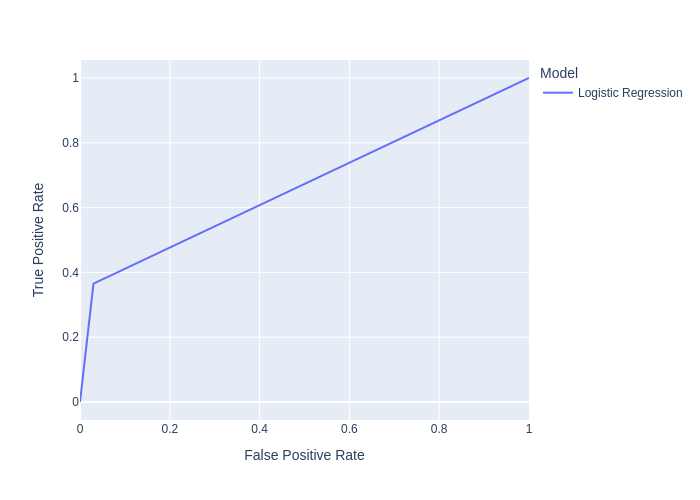

In [17]:
roc_lr_sample = pd.DataFrame({
    'False Positive Rate': lr_fpr_sample,
    'True Positive Rate': lr_tpr_sample,
    'Model': 'Logistic Regression'
}, index=lr_thresholds_sample)


roc_sample_df = pd.concat([roc_lr_sample])


px.line(roc_sample_df, y='True Positive Rate', x='False Positive Rate',
        color='Model',
        width=700, height=500
)

ROC curve shows that our model is predicting the data somewhat better than than a random model, since it has the right curve, it's just that the curve is not as sharp as we would like

In [18]:
from sklearn import metrics
lr_auc_sample = metrics.roc_auc_score(truth_table['truth'], truth_table['prediction'])
print('Logistic regression AUC:', lr_auc_sample.round(3))

Logistic regression AUC: 0.668


AUC value confirms our qualitative analysis in a quantative manner. AUC value is over 0.5, which is better than a random model, but not super close to 0.9 or higher, which would be desired. The AUC value tells us that our model is mediocre

# **Calc the k-fold cv**

In [19]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold

In [20]:
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
# Create empty lists to store the results for each fold
auc_scores = []
accuracy_scores = []
threshold = 0.5
X_val = train_data.drop(['explicit','track_genre'], axis=1)
y_val = train_data['explicit']

for fold, (train_index, test_index) in enumerate(cv.split(X_val, y_val)):
    print(f"Processing fold {fold + 1}/5")

    # Split data into training and testing folds
    X_train_fold, X_test_fold = X_val.iloc[train_index], X_val.iloc[test_index]
    y_train_fold, y_test_fold = y_val.iloc[train_index], y_val.iloc[test_index]

    # Initialize and train the Logistic Regression model
    lr_fold = LogisticRegression(solver='liblinear',class_weight='balanced')
    lr_fold.fit(X_train_fold, y_train_fold)

    # Predict probabilities and binary outcomes on the test fold
    y_pred_proba_fold = lr_fold.predict_proba(X_test_fold)[:, 1]

    # Apply the threshold to get binary predictions
    y_pred_binary_fold = (lr_fold.predict(X_test_fold) > threshold).astype('float')

    # Calculate AUC and accuracy for the fold
    fold_auc = roc_auc_score(y_test_fold, y_pred_proba_fold)
    fold_accuracy = accuracy_score(y_test_fold, y_pred_binary_fold)

    # Store the results
    auc_scores.append(fold_auc)
    accuracy_scores.append(fold_accuracy)

Processing fold 1/5
Processing fold 2/5
Processing fold 3/5
Processing fold 4/5
Processing fold 5/5


In [22]:
# Store the results in a DataFrame
cv_results_df = pd.DataFrame({
    'Fold': range(1, 6),
    'AUC': auc_scores,
    'Accuracy': accuracy_scores
})

# Display the results
print("Cross-validation results:")
print(cv_results_df)
print("Average values: ")
print(cv_results_df.mean())

Cross-validation results:
   Fold       AUC  Accuracy
0     1  0.653285  0.602424
1     2  0.644597  0.599758
2     3  0.704750  0.621899
3     4  0.637730  0.593179
4     5  0.800671  0.726119
Average values: 
Fold        3.000000
AUC         0.688207
Accuracy    0.628676
dtype: float64


k-fold cv AUC is 0.688, and an accuracy of 0.63 shows that our model is correctly predicting about 63% of the time. This model is mediocre but there is high variance between folds which means that the model is has instability.